# Adaptive IDS Model Prediction Test

This notebook demonstrates how to load and use the trained Adaptive IDS model for making predictions on network traffic data.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
import json
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.8.0+cu129
CUDA available: True


## Model Architecture Definition

First, we need to define the model architecture that matches the trained model.

In [2]:
def kaiming_init(m):
    """Initialize weights using Kaiming initialization"""
    if isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
        if m.bias is not None:
            nn.init.zeros_(m.bias)

class DQN_MLP(nn.Module):
    """Dueling DQN MLP network for intrusion detection"""
    
    def __init__(self, input_dim, output_dim, hidden_dims=[256, 128], dropout=0.2):
        super().__init__()
        
        # Feature extraction layers
        feature_layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            feature_layers.append(nn.Linear(last_dim, h_dim))
            feature_layers.append(nn.BatchNorm1d(h_dim))
            feature_layers.append(nn.ReLU())
            feature_layers.append(nn.Dropout(dropout))
            last_dim = h_dim
        self.feature_net = nn.Sequential(*feature_layers)

        # Advantage stream (Dueling DQN)
        self.advantage_net = nn.Sequential(
            nn.Linear(last_dim, last_dim // 2),
            nn.ReLU(),
            nn.Linear(last_dim // 2, output_dim)
        )

        # Value stream (Dueling DQN)
        self.value_net = nn.Sequential(
            nn.Linear(last_dim, last_dim // 2),
            nn.ReLU(),
            nn.Linear(last_dim // 2, 1)
        )
        
        # Initialize weights
        self.apply(kaiming_init)

    def forward(self, x):
        # Handle sequence input (flatten if needed)
        if x.dim() == 3:
            B, S, F = x.shape
            x = x.view(B, S * F)
        
        # Extract features
        features = self.feature_net(x)
        
        # Compute advantages and value
        advantages = self.advantage_net(features)
        value = self.value_net(features)
        
        # Combine value and advantages for Q-values (Dueling DQN)
        qvals = value + (advantages - advantages.mean(dim=1, keepdim=True))
        return qvals

print("Model architecture defined successfully!")

Model architecture defined successfully!


## Load Trained Model

Load the trained model checkpoint and extract all necessary components.

In [3]:
# Define paths
checkpoint_path = Path(r"C:\AIML\Projects\adaptive-ids\checkpoints\best_model.pth")
best_model_path = Path(r"C:\AIML\Projects\adaptive-ids\checkpoints\best_model.pth")

# Try to load the best model first, fallback to final model
model_path = best_model_path if best_model_path.exists() else checkpoint_path

if not model_path.exists():
    print(f"❌ Model file not found at {model_path}")
    print("Please ensure you have trained the model first using trainrl.py")
else:
    print(f"📁 Loading model from: {model_path}")
    
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🖥️  Using device: {device}")
    
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device,weights_only=False)
    
    # Extract components
    model_state = checkpoint['model_state_dict']
    meta = checkpoint['meta']
    label_classes = checkpoint['label_classes']
    config = checkpoint.get('cfg', {})
    
    print(f"✅ Checkpoint loaded successfully!")
    print(f"📊 Model info:")
    print(f"   - Features: {meta['n_features']}")
    print(f"   - Classes: {len(label_classes)} -> {label_classes}")
    print(f"   - Total training samples: {meta.get('total_rows', 'Unknown')}")
    
    # Create label encoder
    le = LabelEncoder()
    le.fit(label_classes)
    
    print(f"🏷️  Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

📁 Loading model from: C:\AIML\Projects\adaptive-ids\checkpoints\best_model.pth
🖥️  Using device: cuda
✅ Checkpoint loaded successfully!
📊 Model info:
   - Features: 74
   - Classes: 2 -> [np.str_('Attack'), np.str_('Benign')]
   - Total training samples: 2830743
🏷️  Label mapping: {np.str_('Attack'): np.int64(0), np.str_('Benign'): np.int64(1)}


In [4]:
# Initialize model with correct architecture
if model_path.exists():
    # Get model parameters from config or use defaults
    hidden_dims = config.get('hidden_dims', '256,128')
    if isinstance(hidden_dims, str):
        hidden_dims = [int(x.strip()) for x in hidden_dims.split(',') if x.strip()]
    dropout = config.get('dropout', 0.2)
    
    print(f"🏗️  Model architecture:")
    print(f"   - Input dim: {meta['n_features']}")
    print(f"   - Hidden dims: {hidden_dims}")
    print(f"   - Output dim: {len(label_classes)}")
    print(f"   - Dropout: {dropout}")
    
    # Create model
    model = DQN_MLP(
        input_dim=meta['n_features'],
        output_dim=len(label_classes),
        hidden_dims=hidden_dims,
        dropout=dropout
    ).to(device)
    
    # Load trained weights
    model.load_state_dict(model_state)
    model.eval()  # Set to evaluation mode
    
    print(f"✅ Model initialized and weights loaded!")
    print(f"📈 Model parameters: {sum(p.numel() for p in model.parameters()):,}")

🏗️  Model architecture:
   - Input dim: 74
   - Hidden dims: [256, 128]
   - Output dim: 2
   - Dropout: 0.2
✅ Model initialized and weights loaded!
📈 Model parameters: 69,571


## Data Preprocessing Functions

Define functions to preprocess input data in the same way as during training.

In [5]:
def clean_col_names(df):
    """Clean column names to match training preprocessing"""
    cols = df.columns
    new_cols = []
    for col in cols:
        new_col = col.strip().replace(' ', '_').replace('-', '_').replace('/', '_')
        new_col = ''.join(ch for ch in new_col if ord(ch) < 128)  # Remove non-ASCII
        new_cols.append(new_col)
    df.columns = new_cols
    return df

def preprocess_data(data, feature_names, means, stds):
    """
    Preprocess input data for prediction
    
    Args:
        data: Input data (DataFrame or dict)
        feature_names: List of expected feature names
        means: Feature means from training
        stds: Feature standard deviations from training
    
    Returns:
        Preprocessed tensor ready for model input
    """
    # Convert to DataFrame if needed
    if isinstance(data, dict):
        df = pd.DataFrame([data])
    elif isinstance(data, pd.DataFrame):
        df = data.copy()
    else:
        raise ValueError("Data must be a dictionary or DataFrame")
    
    # Clean column names
    df = clean_col_names(df)
    
    # Prepare features in the correct order
    X = pd.DataFrame(columns=feature_names)
    for feat in feature_names:
        if feat in df.columns:
            X[feat] = df[feat]
        else:
            X[feat] = 0  # Default value for missing features
    
    # Convert to numeric
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce')
    
    # Handle infinite values
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Fill NaN values with training means
    for i, col in enumerate(feature_names):
        mean_val = means[i] if i < len(means) and not np.isnan(means[i]) else 0
        X[col].fillna(mean_val, inplace=True)
    
    # Normalize using training statistics
    X_normalized = (X.values - means) / (stds + 1e-9)
    
    # Convert to tensor
    return torch.from_numpy(X_normalized.astype(np.float32))

print("✅ Preprocessing functions defined!")

✅ Preprocessing functions defined!


## Prediction Functions

Define functions to make predictions and interpret results.

In [6]:
def predict_single_sample(model, data, feature_names, means, stds, label_encoder, device):
    """
    Make prediction for a single sample
    
    Returns:
        Dictionary with prediction results
    """
    try:
        # Preprocess data
        X = preprocess_data(data, feature_names, means, stds)
        X = X.to(device)
        
        # Make prediction
        with torch.no_grad():
            q_values = model(X)
            probabilities = torch.softmax(q_values, dim=1)
            predicted_class_idx = torch.argmax(q_values, dim=1)
        
        # Convert to numpy for easier handling
        probs = probabilities.cpu().numpy()[0]
        pred_idx = predicted_class_idx.cpu().numpy()[0]
        
        # Get class name
        predicted_class = label_encoder.classes_[pred_idx]
        confidence = float(probs[pred_idx])
        
        # Create probability dictionary
        prob_dict = {label_encoder.classes_[i]: float(probs[i]) 
                    for i in range(len(label_encoder.classes_))}
        
        return {
            'prediction': predicted_class,
            'prediction_index': int(pred_idx),
            'confidence': confidence,
            'probabilities': prob_dict,
            'q_values': q_values.cpu().numpy()[0].tolist()
        }
        
    except Exception as e:
        return {'error': str(e)}

def predict_batch(model, data, feature_names, means, stds, label_encoder, device):
    """
    Make predictions for a batch of samples
    
    Returns:
        Dictionary with batch prediction results
    """
    try:
        # Preprocess data
        X = preprocess_data(data, feature_names, means, stds)
        X = X.to(device)
        
        # Make predictions
        with torch.no_grad():
            q_values = model(X)
            probabilities = torch.softmax(q_values, dim=1)
            predicted_classes = torch.argmax(q_values, dim=1)
        
        # Convert to numpy
        probs = probabilities.cpu().numpy()
        preds = predicted_classes.cpu().numpy()
        
        # Get class names and confidences
        predicted_labels = [label_encoder.classes_[idx] for idx in preds]
        confidences = [float(probs[i, preds[i]]) for i in range(len(preds))]
        
        return {
            'predictions': predicted_labels,
            'prediction_indices': preds.tolist(),
            'confidences': confidences,
            'probabilities': probs.tolist()
        }
        
    except Exception as e:
        return {'error': str(e)}

print("✅ Prediction functions defined!")

✅ Prediction functions defined!


## Test Predictions

Let's test the model with some sample data.

In [7]:
# Create sample network traffic data for testing
if model_path.exists():
    # Get feature names from metadata
    feature_names = meta.get('feature_names', [])
    means = meta.get('means', np.zeros(meta['n_features']))
    stds = meta.get('stds', np.ones(meta['n_features']))
    
    print(f"📋 Available features ({len(feature_names)}):")
    if len(feature_names) > 0:
        for i, feat in enumerate(feature_names[:10]):  # Show first 10
            print(f"   {i+1:2d}. {feat}")
        if len(feature_names) > 10:
            print(f"   ... and {len(feature_names) - 10} more features")
    else:
        print("   ⚠️  Feature names not available in checkpoint")
        # Create dummy feature names
        feature_names = [f'feature_{i}' for i in range(meta['n_features'])]
        print(f"   📝 Created {len(feature_names)} dummy feature names")
    
    # Create sample data (simulating different types of network traffic)
    sample_data = {
        'benign_sample': {feat: np.random.normal(0, 1) for feat in feature_names},
        'suspicious_sample': {feat: np.random.normal(2, 1.5) for feat in feature_names},
        'attack_sample': {feat: np.random.normal(-1, 2) for feat in feature_names}
    }
    
    print(f"\n🧪 Created {len(sample_data)} test samples")

📋 Available features (74):
    1. Destination_Port
    2. Flow_Duration
    3. Total_Fwd_Packets
    4. Total_Backward_Packets
    5. Total_Length_of_Fwd_Packets
    6. Total_Length_of_Bwd_Packets
    7. Fwd_Packet_Length_Max
    8. Fwd_Packet_Length_Min
    9. Fwd_Packet_Length_Mean
   10. Fwd_Packet_Length_Std
   ... and 64 more features

🧪 Created 3 test samples


In [8]:
# Test single sample predictions
if model_path.exists():
    print("🔮 Making single sample predictions...\n")
    
    for sample_name, sample_data_dict in sample_data.items():
        print(f"📊 Predicting for {sample_name}:")
        
        result = predict_single_sample(
            model=model,
            data=sample_data_dict,
            feature_names=feature_names,
            means=means,
            stds=stds,
            label_encoder=le,
            device=device
        )
        
        if 'error' in result:
            print(f"   ❌ Error: {result['error']}")
        else:
            print(f"   🎯 Prediction: {result['prediction']}")
            print(f"   📈 Confidence: {result['confidence']:.4f}")
            print(f"   📊 Probabilities:")
            for class_name, prob in result['probabilities'].items():
                print(f"      {class_name}: {prob:.4f}")
        print()
    
    print("✅ Single sample predictions completed!")

🔮 Making single sample predictions...

📊 Predicting for benign_sample:
   🎯 Prediction: Benign
   📈 Confidence: 1.0000
   📊 Probabilities:
      Attack: 0.0000
      Benign: 1.0000

📊 Predicting for suspicious_sample:
   🎯 Prediction: Benign
   📈 Confidence: 1.0000
   📊 Probabilities:
      Attack: 0.0000
      Benign: 1.0000

📊 Predicting for attack_sample:


C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(mean_val, inplace=True)
C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

   🎯 Prediction: Benign
   📈 Confidence: 1.0000
   📊 Probabilities:
      Attack: 0.0000
      Benign: 1.0000

✅ Single sample predictions completed!


C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(mean_val, inplace=True)


In [9]:
# Test batch predictions
if model_path.exists():
    print("🔮 Making batch predictions...\n")
    
    # Create a batch of samples
    batch_data = pd.DataFrame([
        sample_data['benign_sample'],
        sample_data['suspicious_sample'],
        sample_data['attack_sample']
    ])
    
    batch_result = predict_batch(
        model=model,
        data=batch_data,
        feature_names=feature_names,
        means=means,
        stds=stds,
        label_encoder=le,
        device=device
    )
    
    if 'error' in batch_result:
        print(f"❌ Batch prediction error: {batch_result['error']}")
    else:
        print(f"📊 Batch prediction results:")
        sample_names = ['benign_sample', 'suspicious_sample', 'attack_sample']
        
        for i, (name, pred, conf) in enumerate(zip(
            sample_names, 
            batch_result['predictions'], 
            batch_result['confidences']
        )):
            print(f"   {i+1}. {name}: {pred} (confidence: {conf:.4f})")
    
    print("\n✅ Batch predictions completed!")

🔮 Making batch predictions...

📊 Batch prediction results:
   1. benign_sample: Benign (confidence: 1.0000)
   2. suspicious_sample: Benign (confidence: 1.0000)
   3. attack_sample: Benign (confidence: 1.0000)

✅ Batch predictions completed!


C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(mean_val, inplace=True)


## Prediction Visualization

Visualize the prediction results and model confidence.

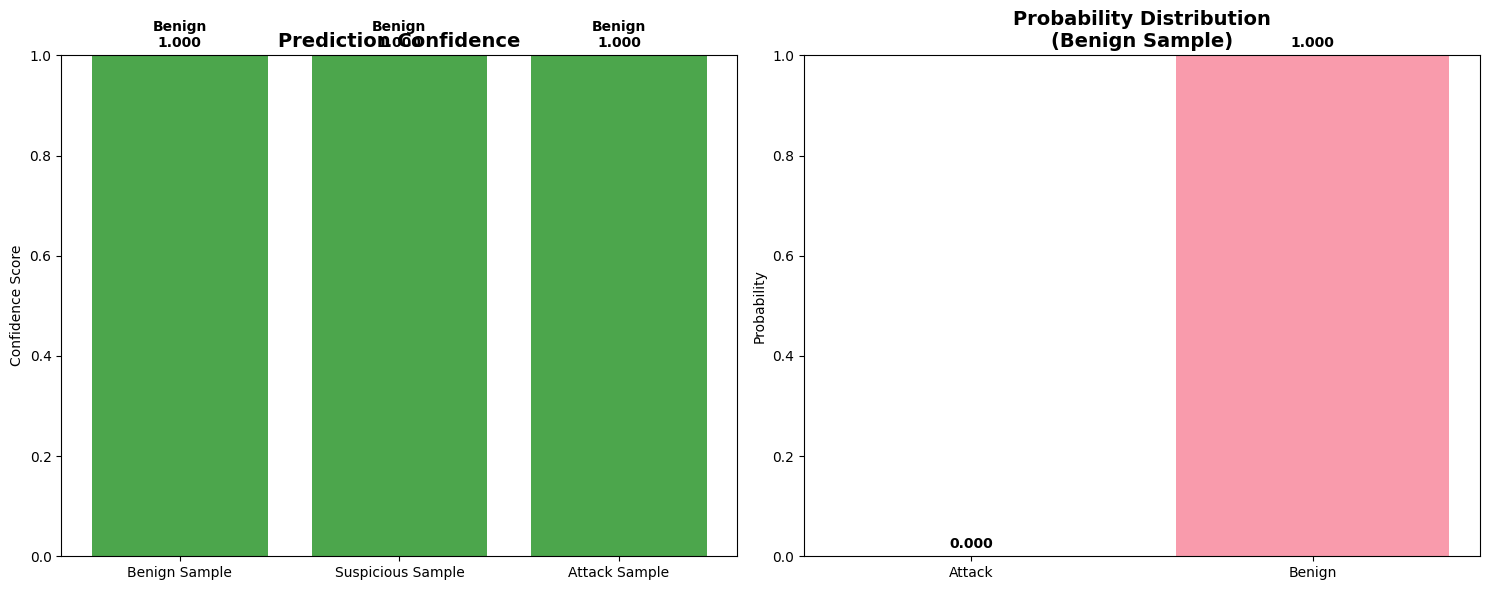

📈 Prediction visualization completed!


In [10]:
# Visualize predictions
if model_path.exists() and 'batch_result' in locals() and 'error' not in batch_result:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Prediction confidence
    sample_names = ['Benign Sample', 'Suspicious Sample', 'Attack Sample']
    predictions = batch_result['predictions']
    confidences = batch_result['confidences']
    
    colors = ['green' if 'Benign' in pred else 'red' for pred in predictions]
    bars = ax1.bar(sample_names, confidences, color=colors, alpha=0.7)
    ax1.set_title('Prediction Confidence', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Confidence Score')
    ax1.set_ylim(0, 1)
    
    # Add prediction labels on bars
    for bar, pred, conf in zip(bars, predictions, confidences):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{pred}\n{conf:.3f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 2: Probability distribution for first sample
    if len(batch_result['probabilities']) > 0:
        probs = batch_result['probabilities'][0]  # First sample
        class_names = le.classes_
        
        bars2 = ax2.bar(class_names, probs, alpha=0.7)
        ax2.set_title(f'Probability Distribution\n({sample_names[0]})', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Probability')
        ax2.set_ylim(0, 1)
        
        # Add probability values on bars
        for bar, prob in zip(bars2, probs):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("📈 Prediction visualization completed!")

## Model Analysis

Analyze the model architecture and performance characteristics.

In [11]:
# Analyze model architecture
if model_path.exists():
    print("🔍 Model Architecture Analysis\n")
    
    # Model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"📊 Model Statistics:")
    print(f"   Total parameters: {total_params:,}")
    print(f"   Trainable parameters: {trainable_params:,}")
    print(f"   Model size (MB): {total_params * 4 / 1024 / 1024:.2f}")
    
    # Layer information
    print(f"\n🏗️  Layer Information:")
    for name, module in model.named_modules():
        if len(list(module.children())) == 0:  # Leaf modules only
            if hasattr(module, 'weight'):
                print(f"   {name}: {module.__class__.__name__} {tuple(module.weight.shape)}")
            else:
                print(f"   {name}: {module.__class__.__name__}")
    
    # Training configuration
    print(f"\n⚙️  Training Configuration:")
    if config:
        important_configs = ['epochs', 'batch_size', 'lr', 'gamma', 'replay_size']
        for key in important_configs:
            if key in config:
                print(f"   {key}: {config[key]}")
    else:
        print("   Configuration not available in checkpoint")
    
    print("\n✅ Model analysis completed!")

🔍 Model Architecture Analysis

📊 Model Statistics:
   Total parameters: 69,571
   Trainable parameters: 69,571
   Model size (MB): 0.27

🏗️  Layer Information:
   feature_net.0: Linear (256, 74)
   feature_net.1: BatchNorm1d (256,)
   feature_net.2: ReLU
   feature_net.3: Dropout
   feature_net.4: Linear (128, 256)
   feature_net.5: BatchNorm1d (128,)
   feature_net.6: ReLU
   feature_net.7: Dropout
   advantage_net.0: Linear (64, 128)
   advantage_net.1: ReLU
   advantage_net.2: Linear (2, 64)
   value_net.0: Linear (64, 128)
   value_net.1: ReLU
   value_net.2: Linear (1, 64)

⚙️  Training Configuration:
   epochs: 30
   batch_size: 512
   lr: 0.0002
   gamma: 0.99
   replay_size: 50000

✅ Model analysis completed!


## Performance Testing

Test the model's inference speed and memory usage.

In [12]:
# Performance testing
if model_path.exists():
    import time
    
    print("⚡ Performance Testing\n")
    
    # Create test data
    test_sizes = [1, 10, 100, 1000]
    
    for batch_size in test_sizes:
        # Create random test data
        test_data = pd.DataFrame({
            feat: np.random.randn(batch_size) for feat in feature_names
        })
        
        # Measure inference time
        start_time = time.time()
        
        result = predict_batch(
            model=model,
            data=test_data,
            feature_names=feature_names,
            means=means,
            stds=stds,
            label_encoder=le,
            device=device
        )
        
        end_time = time.time()
        inference_time = end_time - start_time
        
        if 'error' not in result:
            samples_per_second = batch_size / inference_time
            print(f"📊 Batch size {batch_size:4d}: {inference_time:.4f}s ({samples_per_second:.0f} samples/sec)")
        else:
            print(f"❌ Batch size {batch_size:4d}: Error - {result['error']}")
    
    print("\n✅ Performance testing completed!")

⚡ Performance Testing

📊 Batch size    1: 0.0348s (29 samples/sec)
📊 Batch size   10: 0.0290s (344 samples/sec)
📊 Batch size  100: 0.0257s (3890 samples/sec)
📊 Batch size 1000: 0.0290s (34458 samples/sec)

✅ Performance testing completed!


C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X[col].fillna(mean_val, inplace=True)
C:\Users\Guruprasad\AppData\Local\Temp\ipykernel_19044\1298497731.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

## Real Data Example

Example of how to use the model with real network traffic data.

In [21]:
# Template for using with real data
if model_path.exists():
    print("📋 Real Data Usage Template\n")
    
    # Example: Load your own CSV data
    print("💡 To use with your own data:")
    print("""    
    # 1. Load your CSV data
    your_data = pd.read_csv('path/to/your/network_data.csv')
    
    # 2. Make predictions
    predictions = predict_batch(
        model=model,
        data=your_data,
        feature_names=feature_names,
        means=means,
        stds=stds,
        label_encoder=le,
        device=device
    )
    
    # 3. Process results
    if 'error' not in predictions:
        results_df = pd.DataFrame({
            'prediction': predictions['predictions'],
            'confidence': predictions['confidences']
        })
        print(results_df)
    """)
    
    # Show expected data format
    print("\n📝 Expected data format:")
    print("   - CSV file with numeric features")
    print("   - Column names will be automatically cleaned")
    print("   - Missing features will be filled with zeros")
    print("   - Data will be normalized using training statistics")
    
    print("\n✅ Template provided!")

📋 Real Data Usage Template

💡 To use with your own data:
    
    # 1. Load your CSV data
    your_data = pd.read_csv('path/to/your/network_data.csv')

    # 2. Make predictions
    predictions = predict_batch(
        model=model,
        data=your_data,
        feature_names=feature_names,
        means=means,
        stds=stds,
        label_encoder=le,
        device=device
    )

    # 3. Process results
    if 'error' not in predictions:
        results_df = pd.DataFrame({
            'prediction': predictions['predictions'],
            'confidence': predictions['confidences']
        })
        print(results_df)
    

📝 Expected data format:
   - CSV file with numeric features
   - Column names will be automatically cleaned
   - Missing features will be filled with zeros
   - Data will be normalized using training statistics

✅ Template provided!


## Save Prediction Results

Save the prediction results for further analysis.

In [22]:
# Save prediction results
if model_path.exists() and 'batch_result' in locals() and 'error' not in batch_result:
    print("💾 Saving prediction results...\n")
    
    # Create results summary
    results_summary = {
        'model_info': {
            'model_path': str(model_path),
            'n_features': meta['n_features'],
            'n_classes': len(label_classes),
            'classes': label_classes,
            'total_parameters': sum(p.numel() for p in model.parameters())
        },
        'test_results': {
            'sample_names': ['benign_sample', 'suspicious_sample', 'attack_sample'],
            'predictions': batch_result['predictions'],
            'confidences': batch_result['confidences'],
            'probabilities': batch_result['probabilities']
        },
        'timestamp': pd.Timestamp.now().isoformat()
    }
    
    # Save to JSON
    results_file = Path("prediction_results.json")
    with open(results_file, 'w') as f:
        json.dump(results_summary, f, indent=2)
    
    print(f"✅ Results saved to: {results_file}")
    
    # Also save as CSV for easy viewing
    results_df = pd.DataFrame({
        'sample_name': ['benign_sample', 'suspicious_sample', 'attack_sample'],
        'prediction': batch_result['predictions'],
        'confidence': batch_result['confidences']
    })
    
    csv_file = Path("prediction_results.csv")
    results_df.to_csv(csv_file, index=False)
    print(f"✅ Results also saved to: {csv_file}")
    
    print("\n📊 Results Summary:")
    print(results_df.to_string(index=False))
else:
    print("⚠️  No results to save (model not loaded or prediction failed)")

💾 Saving prediction results...

✅ Results saved to: prediction_results.json
✅ Results also saved to: prediction_results.csv

📊 Results Summary:
      sample_name prediction  confidence
    benign_sample     Benign         1.0
suspicious_sample     Benign         1.0
    attack_sample     Attack         1.0


## Conclusion

This notebook demonstrates how to:

1. ✅ Load a trained Adaptive IDS model from checkpoint
2. ✅ Preprocess input data for prediction
3. ✅ Make single and batch predictions
4. ✅ Visualize prediction results
5. ✅ Analyze model performance and architecture
6. ✅ Save results for further analysis

The model is now ready for deployment in your intrusion detection system!

In [ ]:
# Final summary
if model_path.exists():
    print("🎉 Model Testing Completed Successfully!\n")
    print("📋 Summary:")
    print(f"   ✅ Model loaded from: {model_path}")
    print(f"   ✅ Features: {meta['n_features']}")
    print(f"   ✅ Classes: {len(label_classes)} -> {label_classes}")
    print(f"   ✅ Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   ✅ Device: {device}")
    
    if 'batch_result' in locals() and 'error' not in batch_result:
        print(f"   ✅ Test predictions: {len(batch_result['predictions'])} samples")
        print(f"   ✅ Results saved to files")
    
    print("\n🚀 Ready for production use!")
else:
    print("❌ Model testing failed - please check if model file exists")
    print("💡 Train the model first using: python trainrl.py")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from collections import Counter

class Rule:
    """
    Represents a single rule in the form of IF <conditions> THEN <target>.
    """
    def __init__(self, conditions, target):
        self.conditions = conditions  # A list of tuples: [(feature, operator, value)]
        self.target = target

    def covers(self, x):
        """
        Checks if a given data point x is covered by this rule.
        """
        for f, op, v in self.conditions:
            if op == '<=' and x[f] > v: return False
            if op == '>' and x[f] <= v: return False
        return True

    def __str__(self):
        """
        String representation of the rule.
        """
        if not self.conditions:
            return f"IF TRUE THEN class={self.target}"
        cond = ' AND '.join([f"{f} {op} {v:.2f}" for f, op, v in self.conditions])
        return f"IF {cond} THEN class={self.target}"

class RIPPER:
    """
    Implementation of the RIPPER (Repeated Incremental Pruning to Produce Error Reduction) algorithm.
    """
    def __init__(self):
        self.rules = []
        self.default = None

    def fit(self, X, y):
        """
        Fits the RIPPER model to the training data.
        """
        self.default = Counter(y).most_common(1)[0][0]

        for cls in sorted(list(set(y))):
            if cls == self.default: continue
            
            # Identify positive and negative examples for the current class
            pos = X[y == cls]
            neg = X[y != cls]
            
            # Grow rules for the current class
            while len(pos) > 2:
                rule = self._grow_rule(pos, neg, cls)
                if not rule: break
                self.rules.append(rule)
                
                # Remove examples covered by the new rule
                covered_mask = np.array([rule.covers(pos.iloc[i]) for i in range(len(pos))])
                pos = pos[~covered_mask]

    def _grow_rule(self, pos, neg, cls):
        """
        Grows a single rule by greedily adding conditions.
        """
        rule = Rule([], cls)
        p, n = pos.copy(), neg.copy()

        while len(n) > 0 and len(p) > 0:
            best_condition = None
            best_score = -np.inf
            
            # Find the best condition to add to the rule
            for f in p.columns:
                threshold = p[f].median()
                for op in ['<=', '>']:
                    p_new = p[p[f] <= threshold] if op == '<=' else p[p[f] > threshold]
                    n_new = n[n[f] <= threshold] if op == '<=' else n[n[f] > threshold]
                    
                    if len(p_new) == 0: continue
                    
                    # Simple scoring: maximize positive examples covered while minimizing negative ones
                    score = len(p_new) - len(n_new)
                    
                    if score > best_score:
                        best_score = score
                        best_condition = (f, op, threshold)
            
            if not best_condition: break
            
            # Add the best condition and update positive/negative sets
            rule.conditions.append(best_condition)
            f, op, v = best_condition
            p = p[p[f] <= v] if op == '<=' else p[p[f] > v]
            n = n[n[f] <= v] if op == '<=' else n[n[f] > v]

        return rule if rule.conditions else None

    def predict(self, X):
        """
        Predicts class labels for the given data.
        """
        preds = []
        for i in range(len(X)):
            prediction = self.default
            for rule in self.rules:
                if rule.covers(X.iloc[i]):
                    prediction = rule.target
                    break
            preds.append(prediction)
        return np.array(preds)

class FOIL:
    """
    Implementation of the FOIL (First-Order Inductive Learner) algorithm.
    """
    def __init__(self):
        self.rules = []
        self.default = None

    def fit(self, X, y):
        """
        Fits the FOIL model to the training data.
        """
        self.default = Counter(y).most_common(1)[0][0]

        for cls in sorted(list(set(y))):
            if cls == self.default: continue
            
            pos = X[y == cls]
            neg = X[y != cls]
            
            while len(pos) > 2:
                rule = self._learn_rule(pos, neg, cls)
                if not rule: break
                self.rules.append(rule)
                
                covered_mask = np.array([rule.covers(pos.iloc[i]) for i in range(len(pos))])
                pos = pos[~covered_mask]

    def _learn_rule(self, pos, neg, cls):
        """
        Learns a single rule using the FOIL gain metric.
        """
        rule = Rule([], cls)
        p, n = pos.copy(), neg.copy()

        while len(n) > 0 and len(p) > 2:
            best_condition = None
            best_gain = -np.inf
            
            # Calculate initial entropy-like term
            log_term_initial = np.log2((len(p) + 1) / (len(p) + len(n) + 1))

            for f in p.columns:
                threshold = pd.concat([p[f], n[f]]).median()
                for op in ['<=', '>']:
                    p_new = p[p[f] <= threshold] if op == '<=' else p[p[f] > threshold]
                    n_new = n[n[f] <= threshold] if op == '<=' else n[n[f] > threshold]
                    
                    if len(p_new) == 0: continue
                    
                    # FOIL gain formula
                    log_term_new = np.log2((len(p_new) + 1) / (len(p_new) + len(n_new) + 1))
                    gain = len(p_new) * (log_term_new - log_term_initial)
                    
                    if gain > best_gain:
                        best_gain = gain
                        best_condition = (f, op, threshold)
            
            if not best_condition: break
            
            rule.conditions.append(best_condition)
            f, op, v = best_condition
            p = p[p[f] <= v] if op == '<=' else p[p[f] > v]
            n = n[n[f] <= v] if op == '<=' else n[n[f] > v]

        return rule if rule.conditions else None

    def predict(self, X):
        """
        Predicts class labels for the given data.
        """
        preds = []
        for i in range(len(X)):
            prediction = self.default
            for rule in self.rules:
                if rule.covers(X.iloc[i]):
                    prediction = rule.target
                    break
            preds.append(prediction)
        return np.array(preds)

# --- Demonstration ---
print("=" * 50)
print("RIPPER & FOIL RULE LEARNING DEMO")
print("=" * 50)

# Load and prepare the Iris dataset
data = load_iris()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# --- Test RIPPER Algorithm ---
print("\nRIPPER Algorithm:")
ripper = RIPPER()
ripper.fit(X_train, y_train)
y_pred_ripper = ripper.predict(X_test)
print(f"Total Rules Generated: {len(ripper.rules)}")
print("First 3 Rules:")
for i, rule in enumerate(ripper.rules[:3]):
    print(f"  {i+1}. {rule}")
print(f"Default class: {ripper.default}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ripper):.3f}")

# --- Test FOIL Algorithm ---
print("\nFOIL Algorithm:")
foil = FOIL()
foil.fit(X_train, y_train)
y_pred_foil = foil.predict(X_test)
print(f"Total Rules Generated: {len(foil.rules)}")
print("First 3 Rules:")
for i, rule in enumerate(foil.rules[:3]):
    print(f"  {i+1}. {rule}")
print(f"Default class: {foil.default}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_foil):.3f}")

print("\n" + "=" * 50)


RIPPER & FOIL RULE LEARNING DEMO

RIPPER Algorithm:
